# Viscosity profile

In [1]:
using CairoMakie, GeoParams

thickness = 2890 * km
η0 = 9.8e21
CharDim = GEO_units(;
    length = thickness, viscosity = η0, temperature = 2.800e3K
)

n  = 64
lz = nondimensionalize(2890km, CharDim)
z  = LinRange(-lz, 0, n)


64-element LinRange{Float64, Int64}:
 -1.0, -0.984127, -0.968254, -0.952381, …, -0.031746, -0.015873, 0.0

### Diffusion viscosity

$\eta_{\text{diff}} = A^{-1} \exp( \frac{E + PV}{R  T})$

In [2]:
visc_diff(T, P, A, E, V; R = 8.3145) = A^(-1) * exp((E + P*V) / (R * T))
visc_diff(T, P, data::NamedTuple; R = 8.3145) = visc_diff(T, P, data.A, data.E, data.V; R = R)

visc_diff (generic function with 2 methods)

### Dislocation viscosity

$\eta_{\text{diff}} = \dot{\varepsilon}_{II}^{\frac{1-n}{n}} A^{\frac{-1}{n}} \exp( \frac{E + PV}{n R  T})$

In [3]:
visc_disl(εII, T, P, n, A, E, V; R = 8.3145) = εII^((1-n)/n) * A^(-1/n) * exp((E + P*V) / (n * R * T))
visc_disl(εII, T, P, data::NamedTuple; R = 8.3145) = visc_disl(εII, T, P, data.n, data.A, data.E, data.V; R = R)

visc_disl (generic function with 2 methods)

## Effective viscosity

$\eta = \frac{1}{\frac{1}{\eta}  + \frac{1}{\eta}}$

In [4]:
function visc_eff(εII, T, P,  data_diff::NamedTuple, data_disl::NamedTuple; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
    return η_diff * η_disl / (η_diff +  η_disl)
    return 1 / (1/η_diff +  1/η_disl)
end
function visc_eff(εII, T, P, ::Nothing, data_disl::NamedTuple; R = 8.3145)
    η_disl = visc_disl(εII, T, P, data_disl; R = R)
end
function visc_eff(εII, T, P, data_diff::NamedTuple, ::Nothing; R = 8.3145)
    η_diff = visc_diff(T, P, data_diff; R = R)
end


visc_eff (generic function with 3 methods)

## Initial thermal and pressure profiles

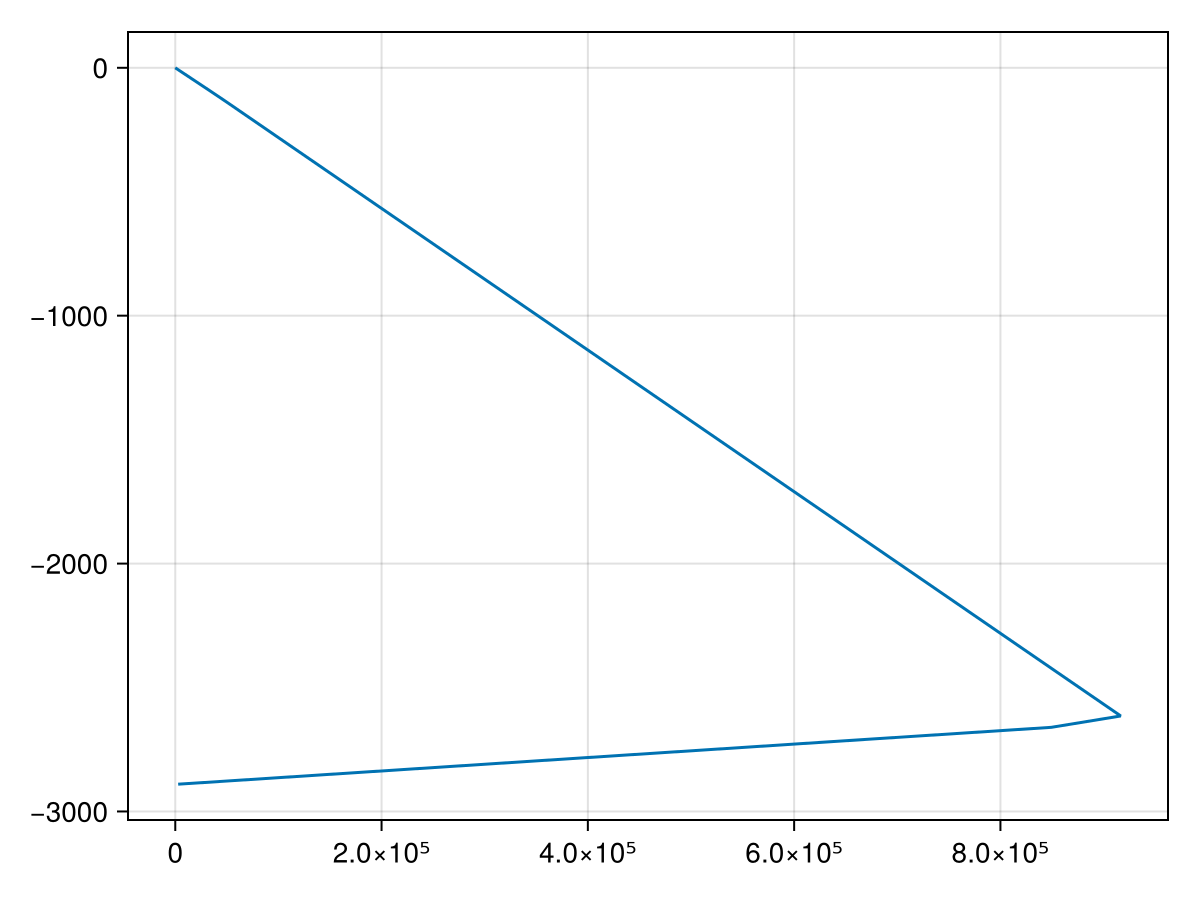

In [5]:
# Smooth switch
S(ξ) = 0.5 * (1.0 + tanh(ξ))

# Interior adiabat
T_ad(z; Tm=1600.0, zm=100.0, gamma=0.35) = Tm + gamma * (z - zm)

function T_field(
    z;
    Lz=2890.0,
    n=1,
    m=1,
    Ttop=273.0,
    Tbot=3800.0,
    Tm=1600.0 + 200,
    zm=100.0,
    gamma=0.35,
    delta_t=120e3,
    delta_b=250e3,
    w_t=20e3,
    w_b=25e3,
)
    # Match conductive boundary layers onto an adiabatic interior.
    s_t = S((z - delta_t) / w_t)
    s_b = S(((Lz - delta_b) - z) / w_b)
    Tad_topmatch = T_ad(delta_t; Tm=Tm, zm=zm, gamma=gamma)
    Tad_botmatch = T_ad(Lz - delta_b; Tm=Tm, zm=zm, gamma=gamma)
    T_topBL = Ttop + (Tad_topmatch - Ttop) * (z / delta_t)
    T_botBL = Tad_botmatch + (Tbot - Tad_botmatch) * ((z - (Lz - delta_b)) / delta_b)
    background = (1.0 - s_t) * T_topBL + (s_t * s_b) * T_ad(z; Tm=Tm, zm=zm, gamma=gamma) + (1.0 - s_b) * T_botBL

    return background
end

z_m = Array(ustrip(dimensionalize(z, m, CharDim)))
T = nondimensionalize(
    T_field.(
        -z_m;
        Lz = @dimstrip(lz, m, CharDim),
        Ttop = 273.0,
        Tbot = 2800.0 + 273,
        Tm = 1350.0 + 273 + 150,
        # delta_b = 250.0,
        w_t = 20,
        w_b = 20
    ) .* K,
    CharDim
)

P = nondimensionalize((@. -3300 * 9.81 * z_m) .* Pa, CharDim)
lines(@dimstrip(T, C, CharDim), @dimstrip(z, km, CharDim))


Mantle thickness                = 2890.0 km
Top boundary layer thickness    = 120.0 km
Bottom boundary layer thickness = 200.0 km
Adiabatic gradient              = 0.377 K/km
Surface temperature             = 273.0 K
Temp at base of top BL          = 1645.2 K
Temp at top of bottom BL        = 2613.3 K
CMB temperature                 = 4000.0 K


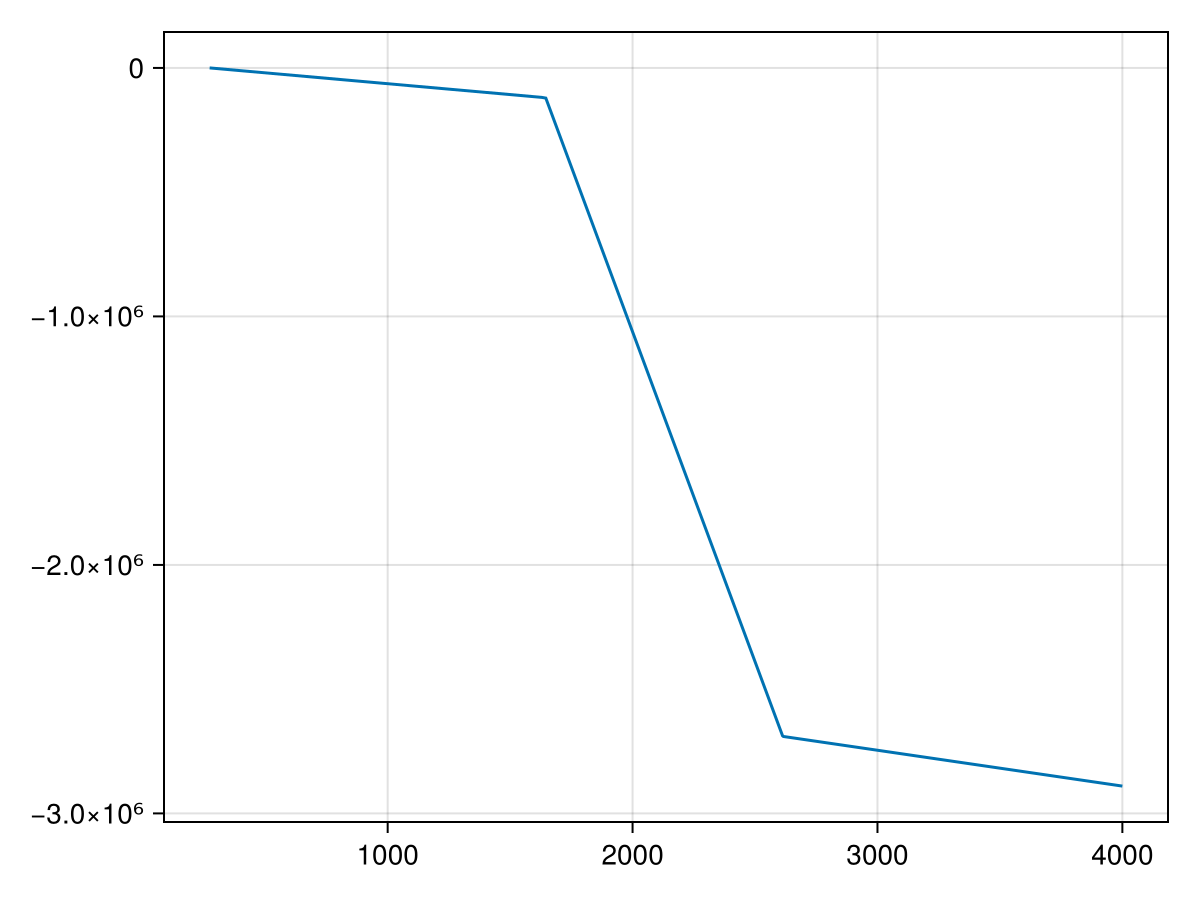

In [6]:
# mantle_profile.jl
#
# Build a 1D Earth-like mantle temperature profile:
# - conductive top boundary layer
# - adiabatic interior
# - conductive bottom boundary layer
#
# Output:
#   z_m                  depth from surface [m]
#   T_K                  temperature [K]
#
# Convention:
#   z = 0 at surface
#   z = H at bottom of model domain

using Printf

# -----------------------------
# Parameters (roughly Earth-like)
# -----------------------------
const H           = 2.89e6          # mantle thickness [m] ~ 2890 km
const Nz          = 1000            # number of grid points

const T_surface   = 273.0           # surface temperature [K]
const T_potential = 1600.0          # mantle potential temperature [K]
const T_cmb       = 4000.0          # temperature at base of mantle / near CMB [K]

const delta_top   = 120e3           # top thermal boundary layer thickness [m]
const delta_bot   = 200e3           # bottom thermal boundary layer thickness [m]

# Adiabatic gradient: dT/dz = alpha * g * T / cp
const alpha       = 3.0e-5          # thermal expansivity [1/K]
const g           = 9.81            # gravity [m/s^2]
const cp          = 1250.0          # heat capacity [J/(kg K)]

# If you want a simpler fixed adiabat instead of computing from alpha*g*T/cp,
# you can override with something like:
# const dTdz_ad = 0.3 / 1e3         # 0.3 K/km in K/m

# -----------------------------
# Derived quantities
# -----------------------------
zT = range(0.0, H, length=Nz)

# Use a constant adiabatic gradient based on potential temperature.
# This gives a realistic order-of-magnitude value (~0.3-0.4 K/km).
dTdz_ad = alpha * g * T_potential / cp   # [K/m]

# Match the interior adiabat to the base of the top boundary layer
T_top_bl_base = T_potential + dTdz_ad * delta_top

# Temperature at top of bottom boundary layer, following the adiabat downward
z_bot_bl_top = H - delta_bot
T_bot_bl_top = T_top_bl_base + dTdz_ad * (z_bot_bl_top - delta_top)

# -----------------------------
# Piecewise temperature profile
# -----------------------------
function temperature_profile(z)
    if z <= delta_top
        # Top conductive boundary layer: linear from surface T to adiabat
        return T_surface + (T_top_bl_base - T_surface) * (z / delta_top)

    elseif z < H - delta_bot
        # Adiabatic interior
        return T_top_bl_base + dTdz_ad * (z - delta_top)

    else
        # Bottom conductive boundary layer: linear from adiabat to CMB temperature
        return T_bot_bl_top + (T_cmb - T_bot_bl_top) * ((z - (H - delta_bot)) / delta_bot)
    end
end

T = [temperature_profile(zi) for zi in zT]

# -----------------------------
# Diagnostics
# -----------------------------
@printf("Mantle thickness                = %.1f km\n", H / 1e3)
@printf("Top boundary layer thickness    = %.1f km\n", delta_top / 1e3)
@printf("Bottom boundary layer thickness = %.1f km\n", delta_bot / 1e3)
@printf("Adiabatic gradient              = %.3f K/km\n", dTdz_ad * 1e3)
@printf("Surface temperature             = %.1f K\n", T_surface)
@printf("Temp at base of top BL          = %.1f K\n", T_top_bl_base)
@printf("Temp at top of bottom BL        = %.1f K\n", T_bot_bl_top)
@printf("CMB temperature                 = %.1f K\n", T_cmb)


# # -----------------------------
# # Optional quick text preview
# # -----------------------------
# println("\nSample values:")
# for frac in (0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0)
#     zi = frac * H
#     Ti = temperature_profile(zi)
#     @printf("depth = %7.1f km, T = %7.1f K\n", zi / 1e3, Ti)
# end
lines(T, -zT)

### Phases as function of depth

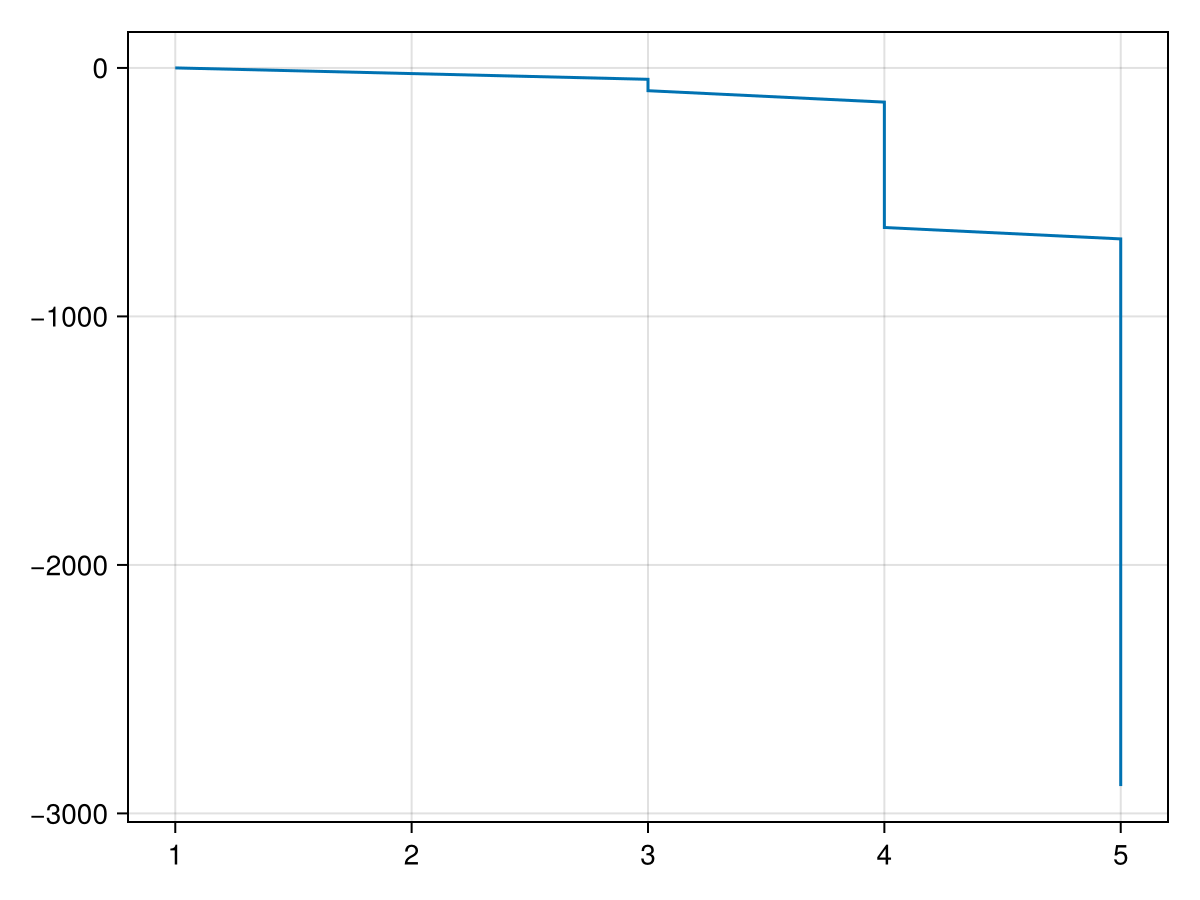

In [7]:
function get_phase(z)
    if z > -nondimensionalize(20e3m, CharDim)
        return 1 # upper crust
    elseif z > -nondimensionalize(40e3m, CharDim)
        return 2 # lower crust
    elseif z > -nondimensionalize(120e3m, CharDim)
        return 3 # lithospheric mantle
    elseif z > -nondimensionalize(660e3m, CharDim)
        return 4 # upper mantle
    else
        return 5 # lower mantle
    end
end

phase = get_phase.(z)
lines(phase, @dimstrip(z, km, CharDim))


## Rheology

Rheologies from Table S2 of [Li et al 2026](https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2025JB032510?saml_referrer)

### Crust

In [8]:
rheo_upper_crust = nondimensionalize(DislocationCreep(
    A = 5.e-18Pa^(-23 // 10) / s,
    n = 2.3NoUnits,
    E = 154.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
), CharDim)

rheo_lower_crust = nondimensionalize(DislocationCreep(
    A = 2e-23Pa^(-32 // 10) / s,
    n = 3.2NoUnits,
    E = 238.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    Apparatus = Invariant,
), CharDim)

DislocationCreep: Name = , n=3.2, r=0.0, A=4.9232974057587794e14 Pa^-3.2 s^-1.0, E=9.860147888132396e-22 J mol^-1.0, V=3.314335424582318e-25 m^3.0 mol^-1.0, FT=1.0, FE=1.0, Apparatus=3

### Lithospheric mantle

In [9]:
# dry olivine
disl_litho = nondimensionalize(DislocationCreep(
    A = 1.58e-15Pa^(-35 // 10) / s,
    n = 3.5NoUnits,
    E = 530.0e3J / mol,
    V = 8.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    # Apparatus = Invariant,
), CharDim)
diff_litho = nondimensionalize(DiffusionCreep(
    A = 2.2e-10Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 375e3J / mol,                  # activation energy
    V = 8-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
), CharDim)
rheo_litho = CompositeRheology(disl_litho, diff_litho)

Unitful.DimensionError: DimensionError: 8 and 6 m^3.0 mol^-1.0 are not dimensionally compatible.

### Upper mantle

In [10]:
# wet olivine
disl_mantle = nondimensionalize(DislocationCreep(
    A = 90MPa^(-35 // 10) / s,
    n = 3.5NoUnits,
    E = 480.0e3J / mol,
    V = 11.0e-6m^3 / mol,
    r = 0.0NoUnits,
    R = 8.3145J / mol / K,
    # Apparatus = Invariant,
), CharDim)
diff_mantle = nondimensionalize(DiffusionCreep(
    A = (10^1)MPa^(-1) * s^(-1),       # material specific rheological parameter
    E = 295e3J / mol,                  # activation energy
    V = 10e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    p = 0NoUnits,                      # grain size exponent
), CharDim)
rheo_mantle = CompositeRheology(disl_mantle, diff_mantle)

--⟦▪̲̅▫̲̅▫̲̅▫̲̅----⟦▪̲̅▫̲̅▫̲̅▫̲̅--


### Lower mantle

In [11]:
rheo_lower_mantle = nondimensionalize(DiffusionCreep(
    A = 2.2e-11Pa^(-1) * s^(-1),       # material specific rheological parameter
    E = 300e3J / mol,                  # activation energy
    V = 2e-6m^3 / mol,                 # activation Volume
    n = 1.0NoUnits,                    # power-law exponent
    r = 0.0NoUnits,                    # exponent of water-fugacity
    d = 2mm,
    p = -0NoUnits,                     # grain size exponent
    # Apparatus = Invariant,
), CharDim)


DiffusionCreep: Name = , n=1.0, r=0.0, p=0.0, A=2.1560000000000003e11 Pa^-1.0 s^-1.0, E=1.242875784218369e-21 J mol^-1.0, V=8.285838561455795e-26 m^3.0 mol^-1.0, FT=1.7320508075688772, FE=1.1547005383792517

### Resulting rheology

In [12]:
rheology = rheo_upper_crust, rheo_lower_crust, rheo_litho, rheo_mantle, rheo_lower_mantle;


UndefVarError: UndefVarError: `rheo_litho` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Compute viscosity profile with GeoParams

In [13]:
εII = nondimensionalize(1e-15 / s, CharDim)
Tnd = nondimensionalize(T*K, CharDim)
η = zeros(n)
for i in eachindex(z)
    phaseᵢ = phase[i]
    Tᵢ = Tnd[i]
    Pᵢ = P[i]
    args = (; T = Tᵢ, P = Pᵢ, dt = Inf)
    η[i] = clamp(
        compute_viscosity_εII(rheology[phaseᵢ], εII, args) * 2,
        nondimensionalize(1e16Pa * s, CharDim),
        nondimensionalize(1e25Pa * s, CharDim)
    )
end
η = @dimstrip η Pa * s CharDim;


UndefVarError: UndefVarError: `rheology` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

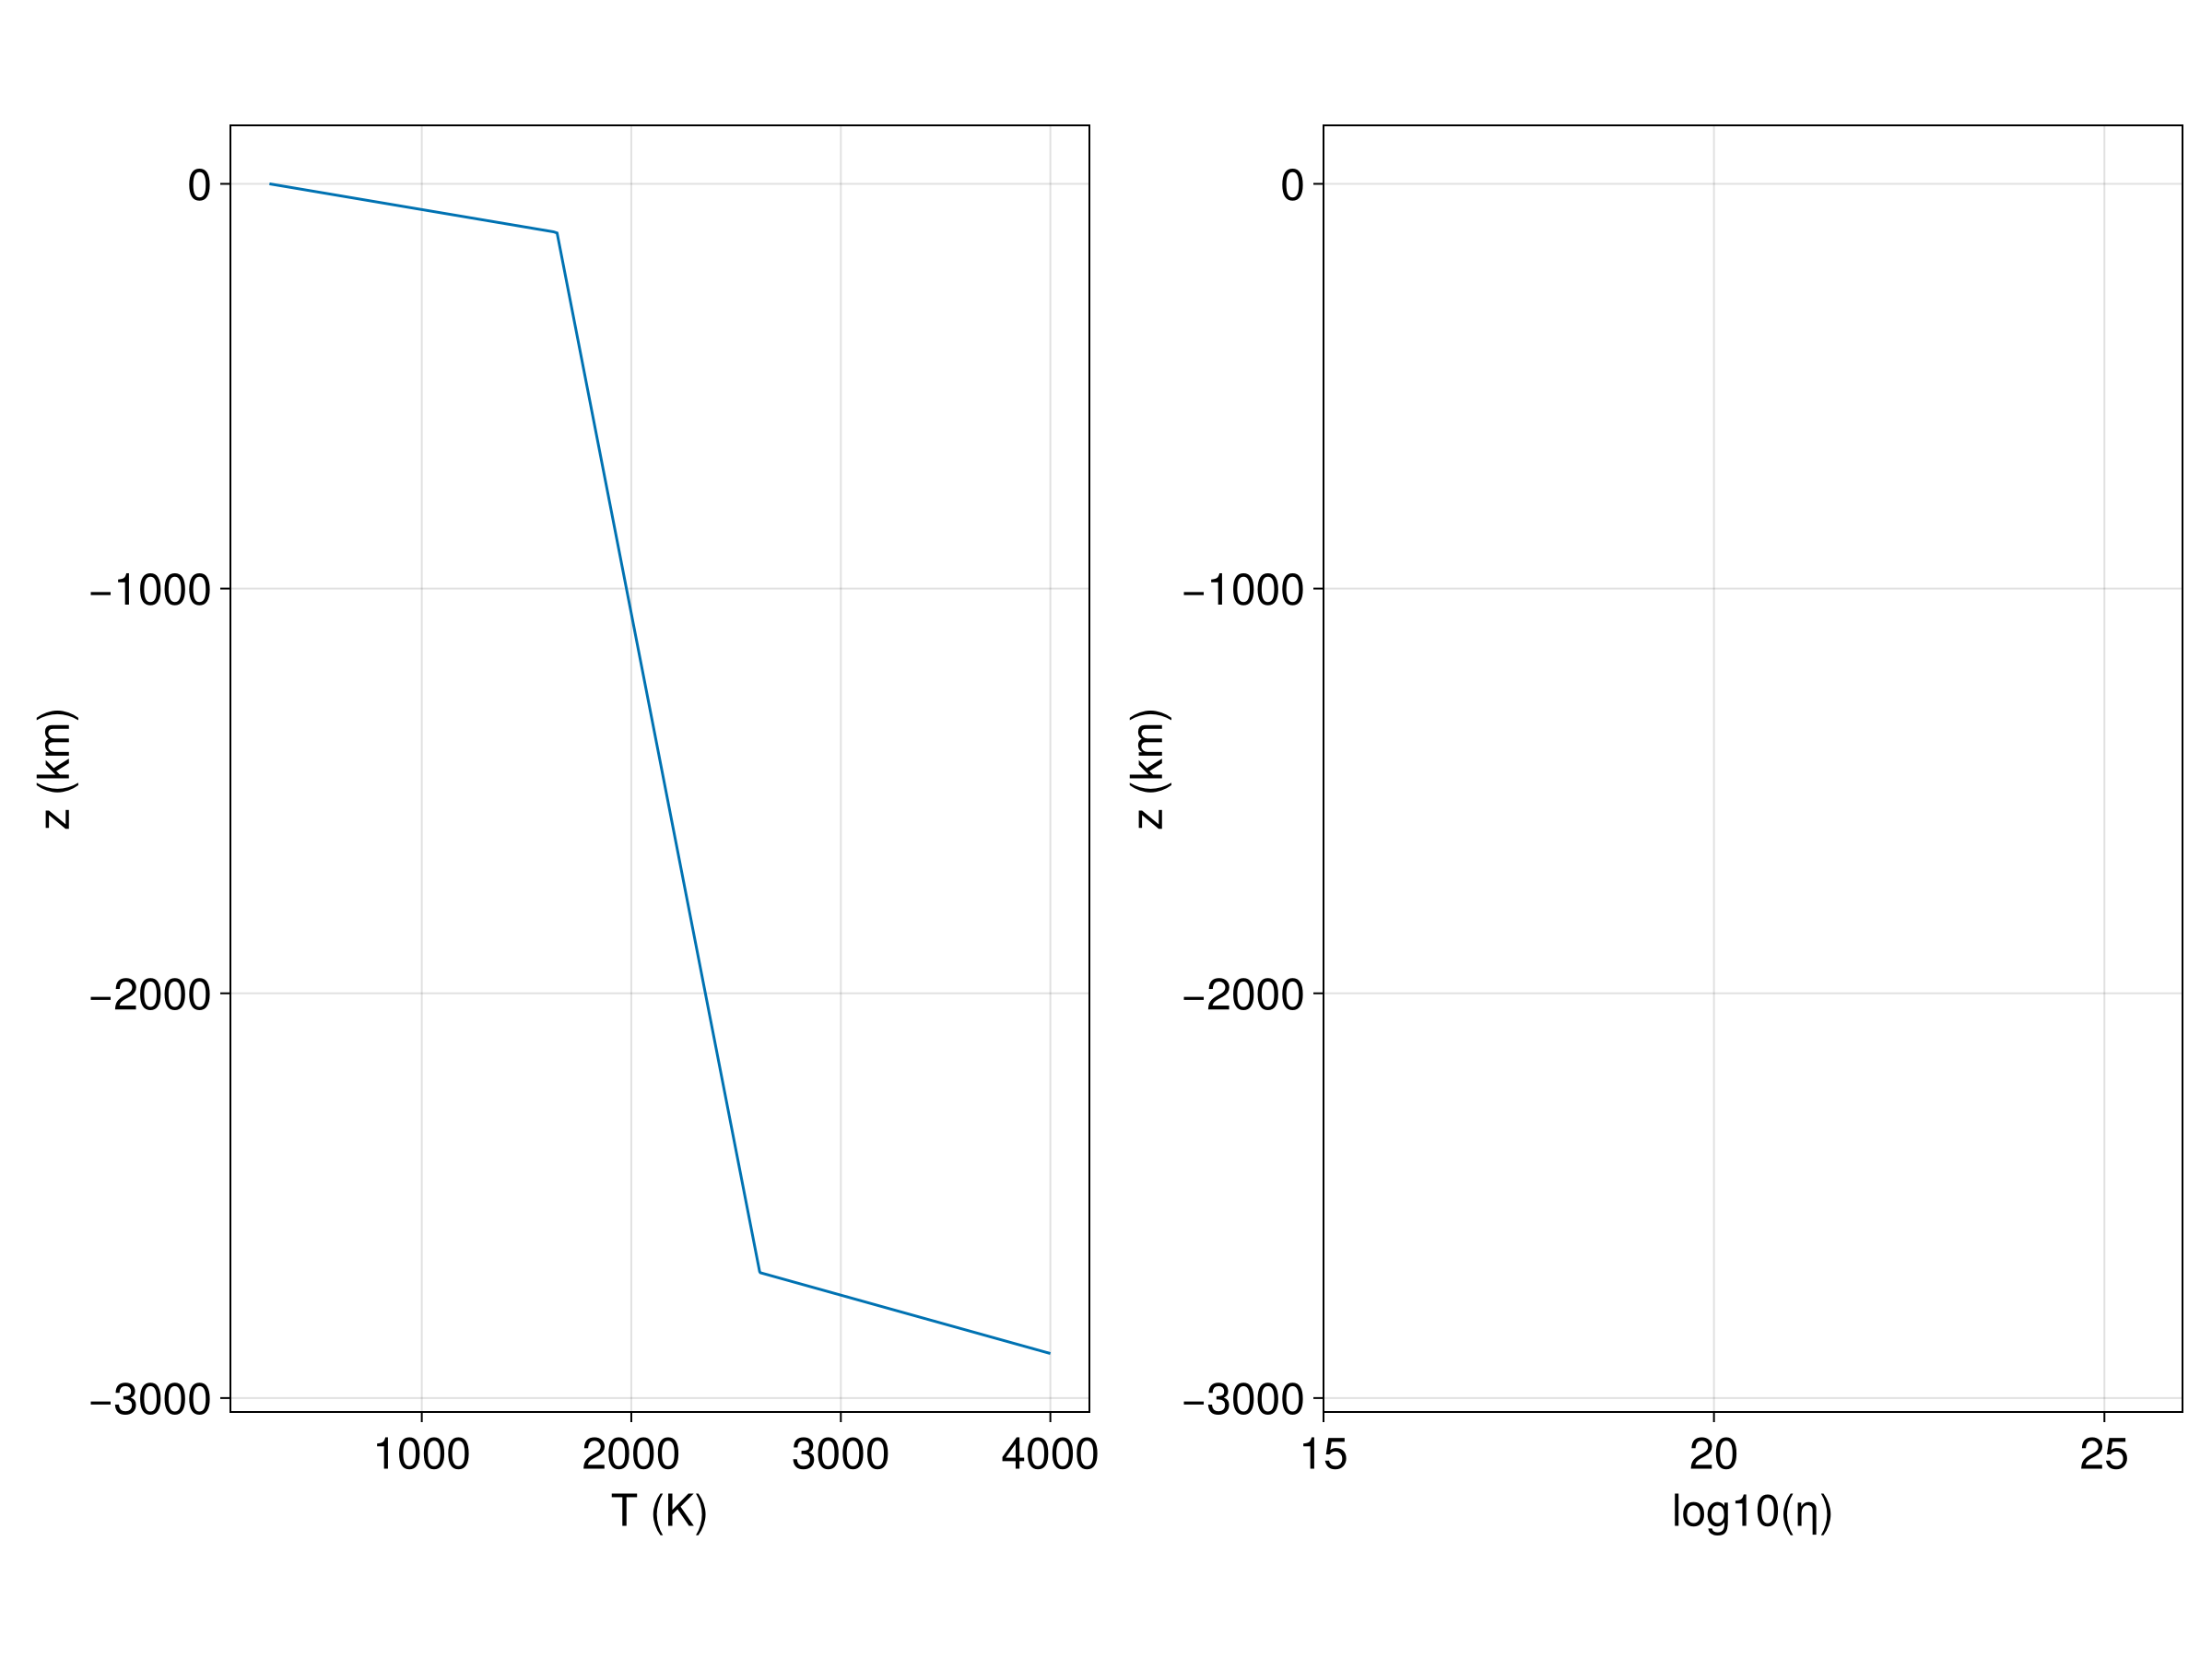

In [14]:
fig = Figure(size = (1200, 900), fontsize = 24)
ax1 = Axis(fig[1, 1], aspect = 2 / 3, ylabel = "z (km)", xlabel = "T (K)")
ax2 = Axis(fig[1, 2], aspect = 2 / 3, ylabel = "z (km)", xlabel = "log10(η)")
lines!(ax1, 
    T, 
    -zT./1e3,
)
lines!(ax2, 
    log10.(η), 
    @dimstrip(z, km, CharDim),
)
xlims!(ax2, 15, 26)
# ylims!(ax2, -1e3, 0)
# ax2.xticks = 19:23.5
fig